In [1]:
import pickle
import torch
from tqdm import tqdm
from minf.data import FieldDataset
from minf.models import Autoencoder, SirenNet
from minf.utils import plot_field
from torch.utils.data import DataLoader
import numpy as np
import yt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

In [2]:
resolution = 16

smiles = ["C1CCCCC1", "CCCCCC"]

fd = FieldDataset(smiles, resolution=resolution, single_property=9, b=1.0)
dl = DataLoader(fd, batch_size=2, shuffle=True)
dl_test = DataLoader(fd, batch_size=2, shuffle=False)

In [3]:
net = SirenNet(
    dim_in=4,
    dim_hidden=256,
    dim_out=1,
    num_layers=8,
    w0 = 1.0,
    w0_initial = 30.0,
    use_bias = True,
    final_activation = None
)

autoencoder = Autoencoder(
    net,
    in_channels=1,
    output_shape=[resolution, resolution, resolution, 1, 1],
    latent_dim=256,
)

autoencoder.cuda()

optim = torch.optim.Adam(lr=1e-4, params=autoencoder.parameters())

/home/daenu/micromamba/envs/minf/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [4]:
for epoch in (pbar := tqdm(range(10000))):
    total_loss = 0
    for batch in dl:
        loss, out, latent = autoencoder(batch.cuda())
        optim.zero_grad()
        loss.backward()
        optim.step()

        total_loss += loss.item()
    torch.save(autoencoder.state_dict(), "model.pt")
    pbar.set_description(f"Epoch {epoch} (loss: {(total_loss / len(fd)):2f})")

Epoch 3445 (loss: 0.001338):  34%|████████████████████████                                              | 3446/10000 [00:35<01:07, 97.44it/s]


KeyboardInterrupt: 

yt : [INFO     ] 2025-02-11 23:35:12,772 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 23:35:12,772 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 23:35:12,772 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 23:35:12,773 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 23:35:12,773 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 23:35:12,831 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 23:35:12,839 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 23:35:12,840 Creating volume
yt : [INFO     ] 2025-02-11 23:35:12,857 Creating transfer function
yt : [INFO     ] 2025-02-11 23:35:12,857 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


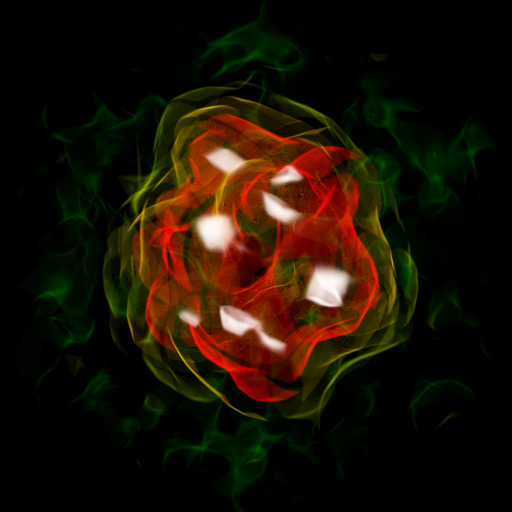

yt : [INFO     ] 2025-02-11 23:35:13,053 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 23:35:13,054 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 23:35:13,054 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 23:35:13,055 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 23:35:13,055 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 23:35:13,096 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 23:35:13,103 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 23:35:13,104 Creating volume
yt : [INFO     ] 2025-02-11 23:35:13,119 Creating transfer function
yt : [INFO     ] 2025-02-11 23:35:13,119 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


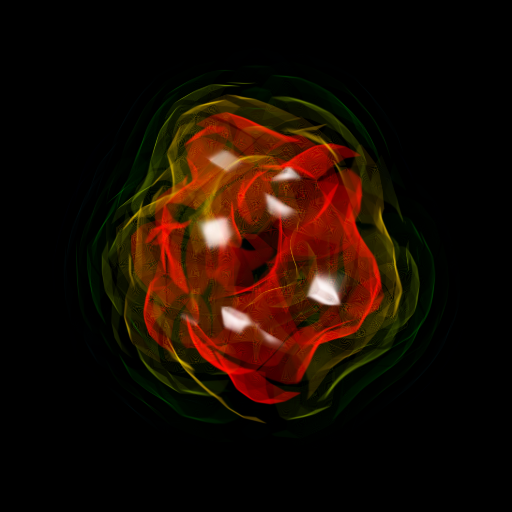

yt : [INFO     ] 2025-02-11 23:35:13,283 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 23:35:13,283 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 23:35:13,283 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 23:35:13,283 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 23:35:13,284 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 23:35:13,326 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 23:35:13,333 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 23:35:13,334 Creating volume
yt : [INFO     ] 2025-02-11 23:35:13,349 Creating transfer function
yt : [INFO     ] 2025-02-11 23:35:13,349 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


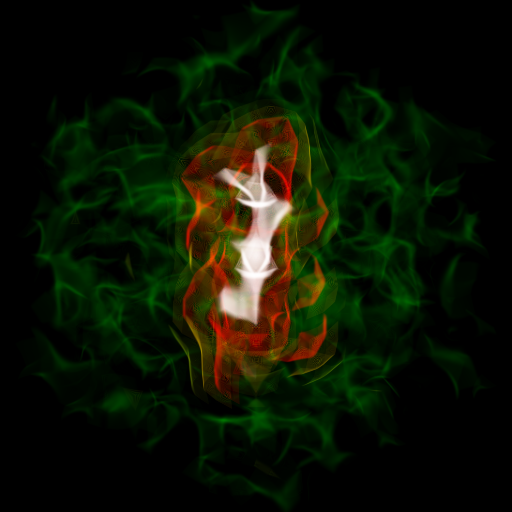

yt : [INFO     ] 2025-02-11 23:35:13,495 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 23:35:13,496 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 23:35:13,496 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 23:35:13,496 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 23:35:13,496 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 23:35:13,539 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 23:35:13,545 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 23:35:13,546 Creating volume
yt : [INFO     ] 2025-02-11 23:35:13,561 Creating transfer function
yt : [INFO     ] 2025-02-11 23:35:13,561 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


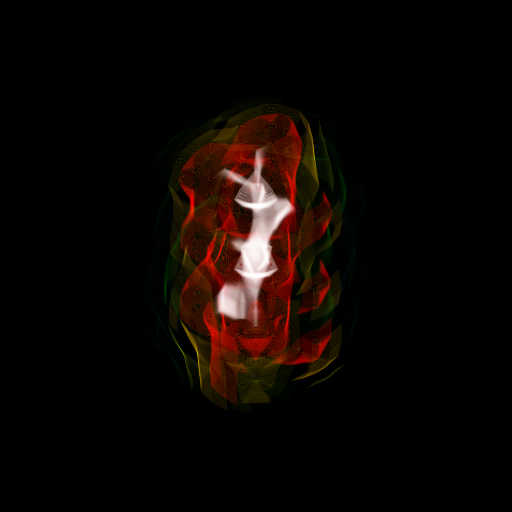

In [5]:
i = 0
for batch in dl_test:
    latent = autoencoder.encode(batch.cuda())
    reconstructed = autoencoder.predict(latent).cpu().detach()
    
    for r in reconstructed:
        plot_field(r.flatten(3)[:, :, :, 0]).show()
        print("gt")
        plot_field(fd[i][:, :, :, 0]).show()
        i += 1
    break

In [6]:
def interp(arr1, arr2, num_points):
    fractions = np.linspace(0, 1, num_points)
    return np.array([arr1 + (arr2 - arr1) * f for f in fractions])

yt : [INFO     ] 2025-02-11 23:35:20,031 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 23:35:20,032 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 23:35:20,032 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 23:35:20,032 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 23:35:20,032 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 23:35:20,076 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 23:35:20,082 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 23:35:20,083 Creating volume
yt : [INFO     ] 2025-02-11 23:35:20,098 Creating transfer function
yt : [INFO     ] 2025-02-11 23:35:20,098 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


(10, 256) torch.Size([256])


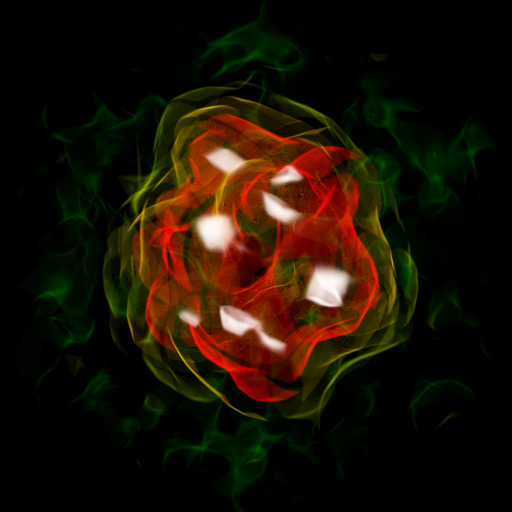

yt : [INFO     ] 2025-02-11 23:35:20,284 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 23:35:20,285 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 23:35:20,285 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 23:35:20,285 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 23:35:20,285 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 23:35:20,328 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 23:35:20,335 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 23:35:20,336 Creating volume
yt : [INFO     ] 2025-02-11 23:35:20,351 Creating transfer function
yt : [INFO     ] 2025-02-11 23:35:20,351 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


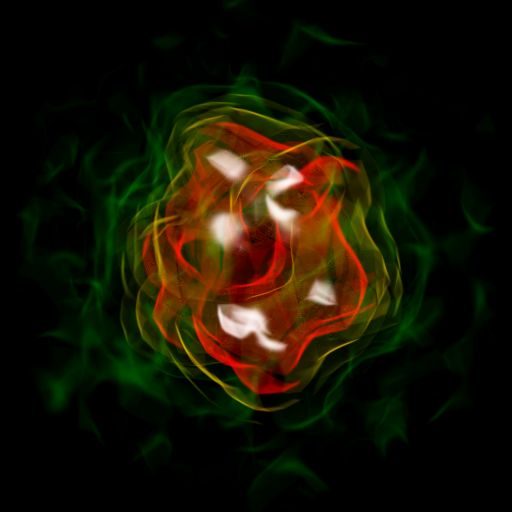

yt : [INFO     ] 2025-02-11 23:35:20,516 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 23:35:20,517 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 23:35:20,517 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 23:35:20,518 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 23:35:20,518 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 23:35:20,558 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 23:35:20,565 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 23:35:20,567 Creating volume
yt : [INFO     ] 2025-02-11 23:35:20,582 Creating transfer function
yt : [INFO     ] 2025-02-11 23:35:20,582 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


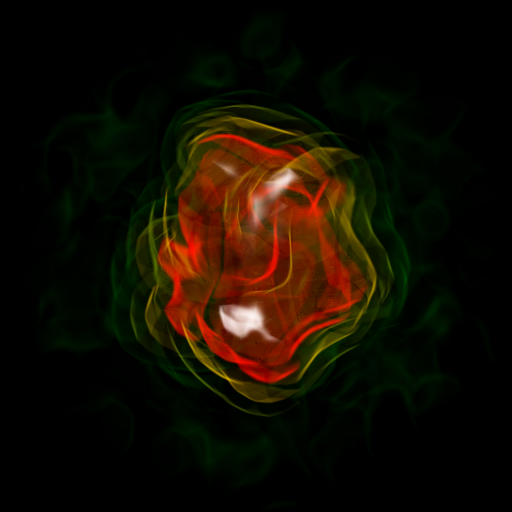

yt : [INFO     ] 2025-02-11 23:35:20,756 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 23:35:20,757 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 23:35:20,757 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 23:35:20,757 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 23:35:20,757 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 23:35:20,873 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 23:35:20,880 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 23:35:20,881 Creating volume
yt : [INFO     ] 2025-02-11 23:35:20,895 Creating transfer function
yt : [INFO     ] 2025-02-11 23:35:20,896 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


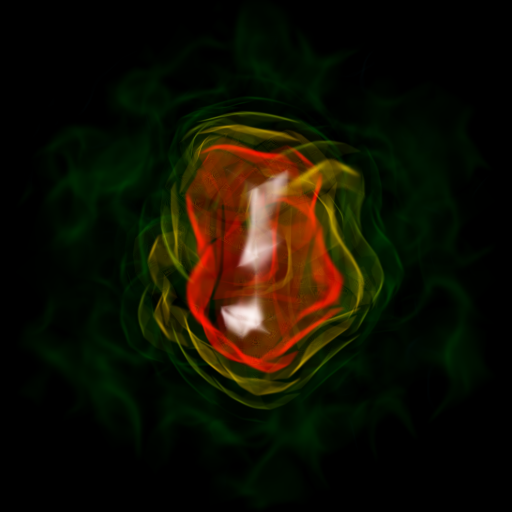

yt : [INFO     ] 2025-02-11 23:35:21,046 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 23:35:21,046 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 23:35:21,046 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 23:35:21,047 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 23:35:21,047 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 23:35:21,092 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 23:35:21,098 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 23:35:21,099 Creating volume
yt : [INFO     ] 2025-02-11 23:35:21,114 Creating transfer function
yt : [INFO     ] 2025-02-11 23:35:21,114 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


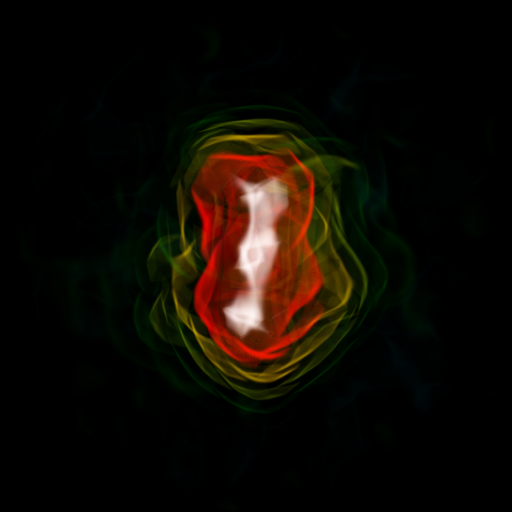

yt : [INFO     ] 2025-02-11 23:35:21,269 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 23:35:21,269 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 23:35:21,269 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 23:35:21,270 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 23:35:21,270 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 23:35:21,310 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 23:35:21,317 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 23:35:21,318 Creating volume
yt : [INFO     ] 2025-02-11 23:35:21,333 Creating transfer function
yt : [INFO     ] 2025-02-11 23:35:21,333 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


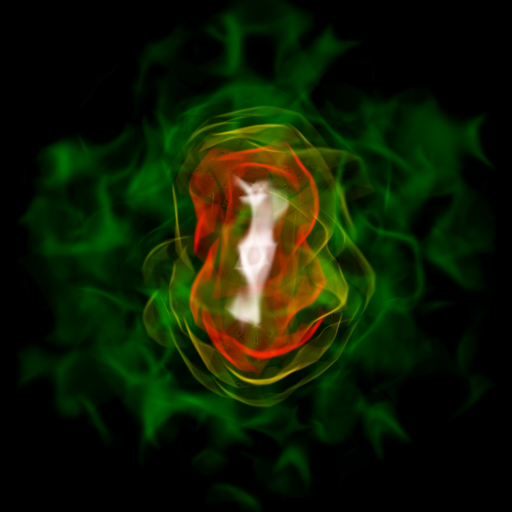

yt : [INFO     ] 2025-02-11 23:35:21,496 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 23:35:21,496 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 23:35:21,496 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 23:35:21,497 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 23:35:21,497 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 23:35:21,538 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 23:35:21,544 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 23:35:21,545 Creating volume
yt : [INFO     ] 2025-02-11 23:35:21,560 Creating transfer function
yt : [INFO     ] 2025-02-11 23:35:21,560 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


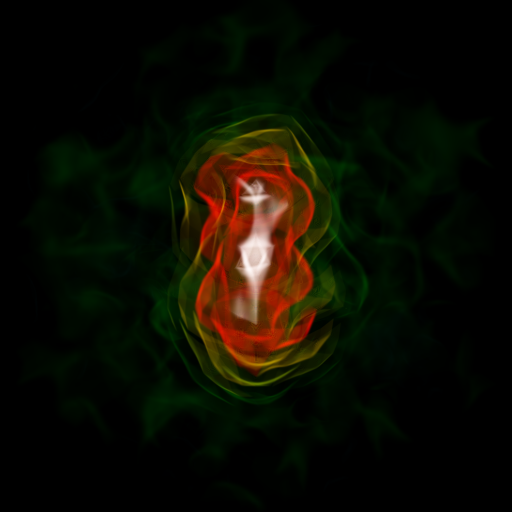

yt : [INFO     ] 2025-02-11 23:35:21,710 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 23:35:21,710 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 23:35:21,710 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 23:35:21,711 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 23:35:21,711 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 23:35:21,751 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 23:35:21,758 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 23:35:21,759 Creating volume
yt : [INFO     ] 2025-02-11 23:35:21,774 Creating transfer function
yt : [INFO     ] 2025-02-11 23:35:21,774 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


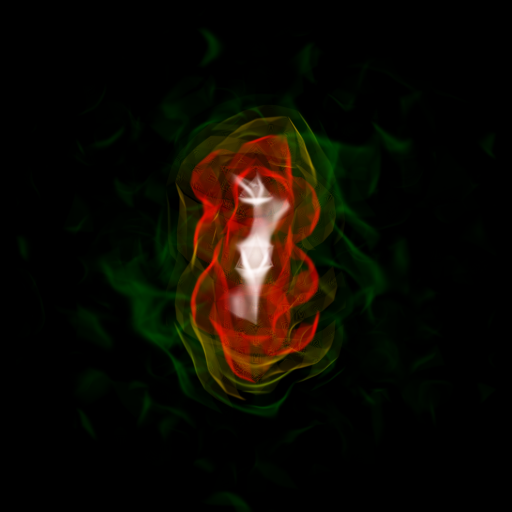

yt : [INFO     ] 2025-02-11 23:35:21,933 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 23:35:21,934 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 23:35:21,934 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 23:35:21,934 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 23:35:21,934 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 23:35:21,975 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 23:35:21,982 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 23:35:21,983 Creating volume
yt : [INFO     ] 2025-02-11 23:35:21,997 Creating transfer function
yt : [INFO     ] 2025-02-11 23:35:21,998 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


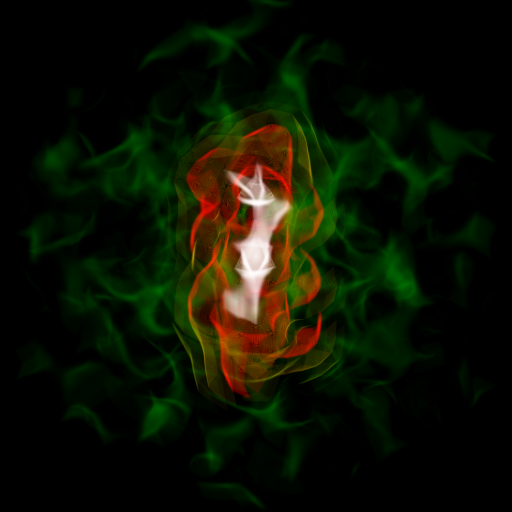

yt : [INFO     ] 2025-02-11 23:35:22,146 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 23:35:22,147 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 23:35:22,147 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 23:35:22,147 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 23:35:22,147 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 23:35:22,189 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 23:35:22,195 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 23:35:22,196 Creating volume
yt : [INFO     ] 2025-02-11 23:35:22,211 Creating transfer function
yt : [INFO     ] 2025-02-11 23:35:22,211 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


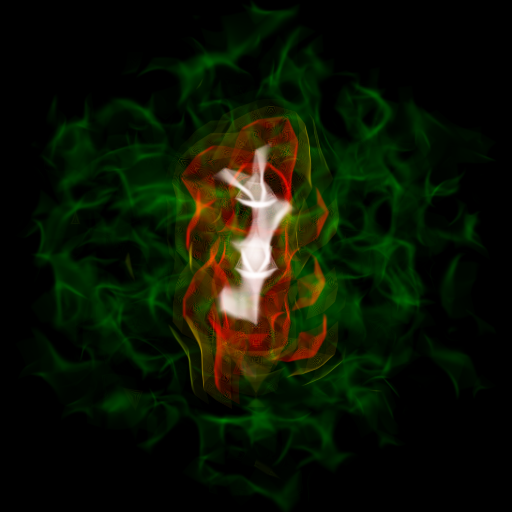

In [7]:
latents = []

for batch in dl_test:
    lats = autoencoder.encode(batch.cuda())
    for lat in lats:
        latents.append(lat.cpu().detach())

latents_intrp = interp(latents[0], latents[1], 10)
print(latents_intrp.shape, latents[0].shape)
reconstructed = autoencoder.predict(torch.FloatTensor(latents_intrp).cuda()).cpu().detach()

for r in reconstructed:
    reconstructed = reconstructed.cpu().detach().squeeze(-1)
    plot_field(r.flatten(3)[:, :, :, 0]).show()